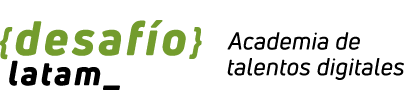
#<center><font color = 'green'>Categorías de datos y series de tiempo</font></center>

## <font color = 'green'>Categorías de datos</font>


### Cross Sectional Data

El siguiente DataFrame y el gráfico que construiremos corresponden a ejemplos de Cross Sectional Data: se trata de una "instantánea" de datos, estáticos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


data = {'País': ['EE. UU.', 'China', 'India', 'Brasil', 'Rusia'],
    'Población (millones)': [330, 1440, 1380, 211, 144],
    'PIB ($ billones)': [21.43, 14.14, 2.87, 2.05, 1.71]}

df = pd.DataFrame(data)
df

In [ ]:
sns.set(style="ticks")
df = sns.load_dataset("diamonds")
sns.distplot(df['price'])

### Times Series Data

In [ ]:
data = {
    'Fecha': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05'],
    'Temperatura (°C)': [18, 19, 17, 20, 21]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'])
plt.plot(df['Fecha'], df['Temperatura (°C)'])
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.title('Ejemplo de Datos de Series Temporales')
plt.xticks(rotation=60)
plt.show()

df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set(style="ticks")
df = sns.load_dataset("flights")
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str), errors='coerce')
df = df.drop(['year', 'month'], axis=1)
df = df.set_index('date')
df['passengers'].plot()

### Panel Data

Como se puede observar, en este caso consideramos datos del mismo país en dos años seguidos.

In [ ]:
import pandas as pd

data = {
    'País': ['EE. UU.', 'EE. UU.', 'China', 'China', 'India', 'India'],
    'Año': [2020, 2021, 2020, 2021, 2020, 2021],
    'PIB ($ billones)': [21.43, 22.67, 14.14, 15.42, 2.87, 3.04]
}

df = pd.DataFrame(data)
df

## <font color = 'green'>Times series</font>

In [ ]:
import sys
import statsmodels as ss
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

### Manejo de datos de tiempo con python

In [ ]:
import datetime as dt

In [ ]:
# Obtener la fecha y hora actual
fecha_hora_actual = dt.datetime.now()
print("Fecha y Hora Actual:", fecha_hora_actual)

# Crear una fecha específica
fecha_especifica = dt.datetime(2023, 6, 15)
print("Fecha Específica:", fecha_especifica)

# Crear una hora específica
hora_especifica = dt.time(14, 30, 0)
print("Hora Específica:", hora_especifica)

In [ ]:
# Formatear fecha y hora en un formato personalizado
fecha_formateada = fecha_hora_actual.strftime("%Y-%m-%d")
print(type(fecha_formateada))
print("Fecha Formateada:", fecha_formateada)

# Analizar una cadena de fecha en un objeto datetime
cadena_fecha = "2023-06-15"
fecha_desde_cadena = dt.datetime.strptime(cadena_fecha, "%Y-%m-%d")
print(type(fecha_desde_cadena))
print("Fecha desde Cadena:", fecha_desde_cadena)


In [ ]:
# Sumar días a una fecha
nueva_fecha = fecha_especifica + dt.timedelta(days=7)
print("Nueva Fecha:", nueva_fecha)

# Calcular la diferencia entre dos fechas
diferencia = nueva_fecha - fecha_especifica
print("Diferencia de Días:", diferencia.days)

In [ ]:
# Crear una duración de tiempo
duracion = dt.timedelta(hours=2, minutes=30)
print("Duración:", duracion)

# Sumar duración a una hora
nueva_hora = fecha_especifica + duracion
print("Nueva Hora:", nueva_hora)

## Manejo de datos con pandas

In [ ]:
import pandas as pd

In [ ]:
# Crear un rango de fechas
fechas = pd.date_range(start='2023-01-01', end='2023-01-10', freq='D')

# Crear un DataFrame con fechas
df = pd.DataFrame({'Fecha': fechas})
print(df)

In [ ]:
# Acceder a componentes de la fecha
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Día'] = df['Fecha'].dt.day

# Filtrar por fecha
df_filtrado = df[df['Fecha'] > '2023-01-05']
print(df_filtrado)

In [ ]:
# Agregar datos por mes
df_mes = df.resample('M', on='Fecha').size()

# Agregar datos por semana
df_semana = df.resample('W-Mon', on='Fecha').size()

print(df_mes)
print(df_semana)

In [ ]:
# Calcular la diferencia entre fechas
diferencia = df['Fecha'].diff()
df['Diferencia'] = diferencia

# Calcular duración acumulada
df['Duración Acumulada'] = df['Diferencia'].cumsum()

print(df)

<center><strong>¡Ahora podemos regresar a nuestra presentación!</strong></center>

## <font color = 'green'> Componentes de series de tiempo</font>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set(style="ticks")


# Cargar el conjunto de datos "Air Passengers" desde seaborn
df = sns.load_dataset("flights")

# Convertir la columna 'year' y 'month' a formato de fecha
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str), errors='coerce')
df = df.drop(['year', 'month'], axis=1)
df = df.set_index('date')
df

In [ ]:
# Descomponer la serie de tiempo en componentes
result = seasonal_decompose(df, model='additive')

In [ ]:
# Descomponer la serie de tiempo en componentes
result = seasonal_decompose(df, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(df, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

plt.tight_layout()
plt.show()


## <font color = 'green'> Modelos de series de tiempo</font>

A continuación aplicaremos lo aprendido respecto de series de tiempo, para lo que utilizaremos algunas series generadas de maneras diferentes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima.model import ARIMA

# Generar una serie de tiempo ficticia
np.random.seed(0)
n = 100
time_series_rand = np.cumsum(np.random.randn(n))

# Generar una serie de tiempo estacionaria
np.random.seed(42)
time_index = pd.date_range(start='2023-01-01', periods=100, freq='D')
seasonal_data = np.sin(2 * np.pi * 0.1 * np.arange(100))
noise = np.random.normal(0, 0.5, size=100)
time_series = seasonal_data + noise

# Crear un DataFrame de pandas
data = pd.DataFrame({'Date': time_index, 'Value': time_series})
data.set_index('Date', inplace=True)

plt.plot(time_series_rand)

data.plot()

##ACF y PACF

Vamos a calcular y graficar ahora el ACF y PACF para cada serie de datos

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Subplot 1 - ACF de 'time_series_rand'
plot_acf(time_series_rand, lags=20, title="ACF - Rand", alpha=0.05, ax=axes[0, 0])

# Subplot 2 - PACF de 'time_series_rand'
plot_pacf(time_series_rand, lags=20, title="PACF - Rand", alpha=0.05, ax=axes[0, 1])

# Subplot 3 - ACF de 'data'
plot_acf(data, lags=20, title="ACF - Estacionaria", alpha=0.05, ax=axes[1, 0])

# Subplot 4 - PACF de 'data'
plot_pacf(data, lags=20, title="PACF - Estacionaria", alpha=0.05, ax=axes[1, 1])

# Ajustar el espaciado entre subplots para que no se superpongan
plt.tight_layout()

# Mostrar la figura
plt.show()


Como podemos ver, en ambos casos, se grafica una zona dentro de la cual los valores de p no son significativos, es decir, no se puede considerar una correlación suficiente como para decir que se podrá predecir un valor en base a los anteriores.

En general, para construir modelos para series de tiempo escogeremos valores de p que sean lo menores posibles (para no complejizar el modelo) pero que a la vez presenten correlación significativa. No existe un criterio único para ello y podemos probar tanto el último valor para el cual la correlación es significativa, o el primer caso en el que entra a la zona de no significatividad.

Podemos observar, además, que en la serie aleatoria (no estacionaria), la ACF decae lentamente y no muestra un patrón claro.  En el caso de la serie estacionaria, la ACF decae rápidamente a medida que aumentan los rezagos. Por lo general, solo hay autocorrelaciones significativas en los primeros rezagos y luego se vuelven no significativas.

Por otra parte, la PACF de una serie aleatoria generalmente no muestra patrones claros, mientras que la de una serie estacionaria a menudo muestra puntos altos y bajos significativos en los primeros rezagos (por lo general, en los primeros 1 o 2 rezagos). Después de estos primeros máximos, las autocorrelaciones parciales se vuelven no significativas.

En resumen, las principales diferencias radican en la rapidez con la que decaen las autocorrelaciones en la ACF y PACF. En una serie aleatoria, las autocorrelaciones pueden extenderse por múltiples rezagos, mientras que en una serie estacionaria, tienden a ser más pronunciadas en los primeros rezagos y luego disminuyen. La presencia de puntos altos significativos en los primeros rezagos de la PACF en una serie estacionaria puede indicar el orden de los términos autoregresivos (AR) en un modelo de series temporales, lo que es importante en análisis y modelado de series temporales.

### Modelos de series de tiempo

Vamos a utilizar nuestra serie estacionaria ahora para construir nuestros modelos. Retomaremos para ello el cálculo de ACF y PACG, para escoger los valores adecuados de p y q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# Subplot 1 - ACF de 'data'
plot_acf(data, lags=20, title="ACF - Estacionaria", alpha=0.05, ax=axes[0])

# Subplot 2 - PACF de 'data'
plot_pacf(data, lags=20, title="PACF - Estacionaria", alpha=0.05, ax=axes[1])

# Ajustar el espaciado entre subplots para que no se superpongan
plt.tight_layout()

# Mostrar la figura
plt.show()

Como hemos mencionado, no hay una regla única para la elección de p(en el caso de un modelo autorregresivo) como de q (para un modelo de medias móviles). Como mencionamos, buscamos en ambos casos un valor que sea significativo (o lo más significativo posible) pero que a la vez no sea demasiado alto, para no complejizar demasiado.

Para elegir el valor de p utilizaremos la PACF, y escogeremos el valor p = 3 ya que es un valor significativo, pero no demasiado alto. Para el caso de q, utilizaremos la ACF y seleccionamos q = 2 (que si bien está en el límite de significatividad, al menos es un poco mayor que 1)

In [ ]:
p = 3
q = 2

Vamos a construir ahora nuestros modelos y compararlos. Para ello, utilizaremos el comando ARIMA, que considera parámetros p, d y q. Si d = 0 y q = 0 tenemos un modelo autorregresivo simple, mientras que con p = 0 tendremos un modelo de medias móviles.

In [ ]:
model_ar = ARIMA(data, order=(p, 0, 0))
model_ar_fit = model_ar.fit()

model_ma = ARIMA(data, order=(0, 0, q))
model_ma_fit = model_ma.fit()

In [ ]:
# Hacer predicciones
predictions_ar = model_ar_fit.predict(start=p, end=len(data)-1, dynamic=False)

# Hacer predicciones
predictions_ma = model_ma_fit.predict(start=q, end=len(data)-1, dynamic=False)



In [ ]:

# Crear una figura con dos subplots en una fila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1 - Gráfico izquierdo
axes[0].plot(data.index, data['Value'], label='Real Data')
axes[0].plot(data.index[p:], predictions_ar, label='Predicted Data AR')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Valor')
axes[0].set_title('Comparación de Predicciones y Datos Reales - AR')
axes[0].legend()

# Subplot 2 - Gráfico derecho
axes[1].plot(data.index, data['Value'], label='Real Data')
axes[1].plot(data.index[q:], predictions_ma, label='Predicted Data MA')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].set_title('Comparación de Predicciones y Datos Reales - MA')
axes[1].legend()

# Ajustar el espaciado entre subplots para que no se superpongan
plt.tight_layout()

# Mostrar la figura
plt.show()

### ARIMA

Vaos a integrar nuestros modelos anteriores construyendo el modelo ARIIMA. Para ello, utilizaremos lo que ya hemos calculado además del test de Dickey - Fuller


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Realizar el test de Dickey-Fuller
result = adfuller(data['Value'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

Considerando esto, establecemos el valor de d dependiendo del resultado en el test: p_value < 0.05 establecemos d=0, en caso contrario d=1 (como ocurre ahora)

In [ ]:
d = 1

# Ajustar el modelo ARIMA con los valores seleccionados
model_arima = ARIMA(data['Value'], order=(p, d, q))
model_arima_fit = model_arima.fit()

In [ ]:
# Hacer predicciones
predictions_arima = model_arima_fit.predict(start=d, end=len(data)-1)

Veremos los resultados comparados ahora, para los tres modelos.

In [ ]:
# Crear una figura con dos subplots en una fila
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Subplot 1 - Gráfico izquierdo
axes[0].plot(data.index, data['Value'], label='Real Data')
axes[0].plot(data.index[p:], predictions_ar, label='Predicted Data AR')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Valor')
axes[0].set_title('Comparación de Predicciones y Datos Reales - AR')
axes[0].legend()

# Subplot 2 - Gráfico derecho
axes[1].plot(data.index, data['Value'], label='Real Data')
axes[1].plot(data.index[q:], predictions_ma, label='Predicted Data MA')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].set_title('Comparación de Predicciones y Datos Reales - MA')
axes[1].legend()


# Subplot 3 - Gráfico derecho
axes[2].plot(data.index, data['Value'], label='Real Data')
axes[2].plot(data.index[d:], predictions_arima, label='Predicted Data ARIMA')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Valor')
axes[2].set_title('Comparación de Predicciones y Datos Reales - Arima')
axes[2].legend()

# Ajustar el espaciado entre subplots para que no se superpongan
plt.tight_layout()

# Mostrar la figura
plt.show()

In [ ]:
from statsmodels.tools.eval_measures import mse, rmse, meanabs

# Calcular las métricas para el modelo AR
mse_ar = mse(data['Value'][p:], predictions_ar)
rmse_ar = rmse(data['Value'][p:], predictions_ar)
mae_ar = meanabs(data['Value'][p:], predictions_ar)

# Calcular las métricas para el modelo MA
mse_ma = mse(data['Value'][q:], predictions_ma)
rmse_ma = rmse(data['Value'][q:], predictions_ma)
mae_ma = meanabs(data['Value'][q:], predictions_ma)

# Calcular las métricas para el modelo ARIMA
mse_arima = mse(data['Value'][d:], predictions_arima)
rmse_arima = rmse(data['Value'][d:], predictions_arima)
mae_arima = meanabs(data['Value'][d:], predictions_arima)

# Imprimir las métricas para cada modelo
print("Métricas del modelo AR:")
print(f"MSE: {mse_ar:.2f}")
print(f"RMSE: {rmse_ar:.2f}")
print(f"MAE: {mae_ar:.2f}")
print()

print("Métricas del modelo MA:")
print(f"MSE: {mse_ma:.2f}")
print(f"RMSE: {rmse_ma:.2f}")
print(f"MAE: {mae_ma:.2f}")
print()

print("Métricas del modelo ARIMA:")
print(f"MSE: {mse_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")
print(f"MAE: {mae_arima:.2f}")




Según las métricas proporcionadas, el modelo ARIMA parece ser el más preciso entre los tres modelos en términos de MSE, RMSE y MAE. Tener valores más bajos en estas métricas indica una mejor capacidad de predicción. Sin embargo, la elección del modelo también debe considerar otros factores, como la simplicidad y la interpretabilidad del modelo.

###AUTO ARIMA

La biblioteca pdmarima nos provee del comando auto_arima, que optimiza la elección de los parámetros para el modelo arima.

In [ ]:
#!pip install pmdarima #importante
from pmdarima import auto_arima

# Ajustar el modelo ARIMA con auto_arima

model_auto_arima = auto_arima(data, seasonal=True, m=10)
p, d, q = model_auto_arima.get_params()['order']

print(p,d,q)


